<a href="https://colab.research.google.com/github/samuel-1-avson/RGT-NSS/blob/main/GPT_Decoder.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<a name="setup"></a>
## 1. Setup & Introduction

In [33]:
# Install required libraries
!pip install transformers torch accelerate --quiet

print("✅ Installation complete!")

✅ Installation complete!


In [34]:
import torch
from transformers import (
    GPT2Tokenizer,
    GPT2LMHeadModel,
    GPT2Config,
    pipeline,
    AutoTokenizer,
    AutoModelForCausalLM,
    TextGenerationPipeline
)
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import HTML

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🔥 Using device: {device}")

# Load GPT-2 tokenizer and model
tokenizer = GPT2Tokenizer.from_pretrained('gpt2')
model = GPT2LMHeadModel.from_pretrained('gpt2')
model.to(device)

print(f"✅ Loaded GPT-2")
print(f"📊 Model parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"📏 Context window: {model.config.n_positions:,} tokens")

🔥 Using device: cpu


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ Loaded GPT-2
📊 Model parameters: 124,439,808
📏 Context window: 1,024 tokens


<a name="architecture"></a>
## 2. GPT Architecture Deep Dive

### 2.1 Key Difference from BERT

```
┌─────────────────────────────────────────────────────────────┐
│                      GPT ARCHITECTURE                        │
├─────────────────────────────────────────────────────────────┤
│  Input: "The cat sat"                                       │
│                              ↓                               │
│  ┌─────────────────────────────────────────────────────┐    │
│  │            CAUSAL (MASKED) DECODER                   │    │
│  │                                                      │    │
│  │  Layer 1:  [The] → [cat] → [sat] → [?]              │    │
│  │              ↓        ↓        ↓                      │    │
│  │  Layer 6:  [The] → [cat] → [sat] → [?]              │    │
│  │              ↓        ↓        ↓                      │    │
│  │  Layer 12: [The] → [cat] → [sat] → [?]              │    │
│  │                                                      │    │
│  │  Each token can ONLY attend to PREVIOUS tokens!      │    │
│  │  (Look-ahead mask prevents seeing future)            │    │
│  └─────────────────────────────────────────────────────┘    │
│                              ↓                               │
│  Output: Predict next token → "on"                          │
│          Then: "The cat sat on" → predict → "the"         │
│          Then: "The cat sat on the" → predict → "mat"     │
└─────────────────────────────────────────────────────────────┘
```

### 2.2 Causal (Masked) Self-Attention

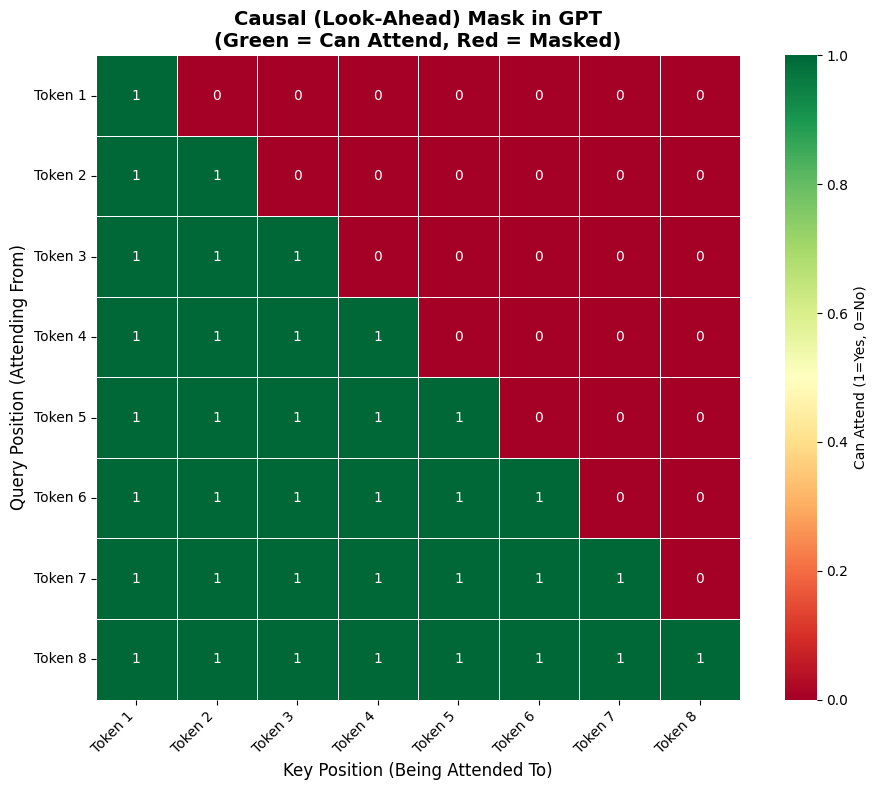


💡 Key Insight:
   Token 5 can only attend to Tokens 1-5 (not 6-10)
   This prevents the model from 'cheating' by looking ahead!


In [35]:
# Visualize the causal attention mask
def visualize_causal_mask(seq_length=10):
    """Visualize the causal (look-ahead) mask used in GPT."""
    # Create causal mask (upper triangular matrix of ones)
    mask = np.tril(np.ones((seq_length, seq_length)))

    plt.figure(figsize=(10, 8))
    sns.heatmap(mask,
                cmap='RdYlGn',
                annot=True,
                fmt='.0f',
                cbar_kws={'label': 'Can Attend (1=Yes, 0=No)'},
                square=True,
                linewidths=0.5)

    tokens = [f'Token {i+1}' for i in range(seq_length)]
    plt.xticks(np.arange(seq_length) + 0.5, tokens, rotation=45, ha='right')
    plt.yticks(np.arange(seq_length) + 0.5, tokens, rotation=0)

    plt.title('Causal (Look-Ahead) Mask in GPT\n(Green = Can Attend, Red = Masked)',
              fontsize=14, fontweight='bold')
    plt.xlabel('Key Position (Being Attended To)', fontsize=12)
    plt.ylabel('Query Position (Attending From)', fontsize=12)
    plt.tight_layout()
    plt.show()

    print("\n💡 Key Insight:")
    print("   Token 5 can only attend to Tokens 1-5 (not 6-10)")
    print("   This prevents the model from 'cheating' by looking ahead!")

visualize_causal_mask(8)

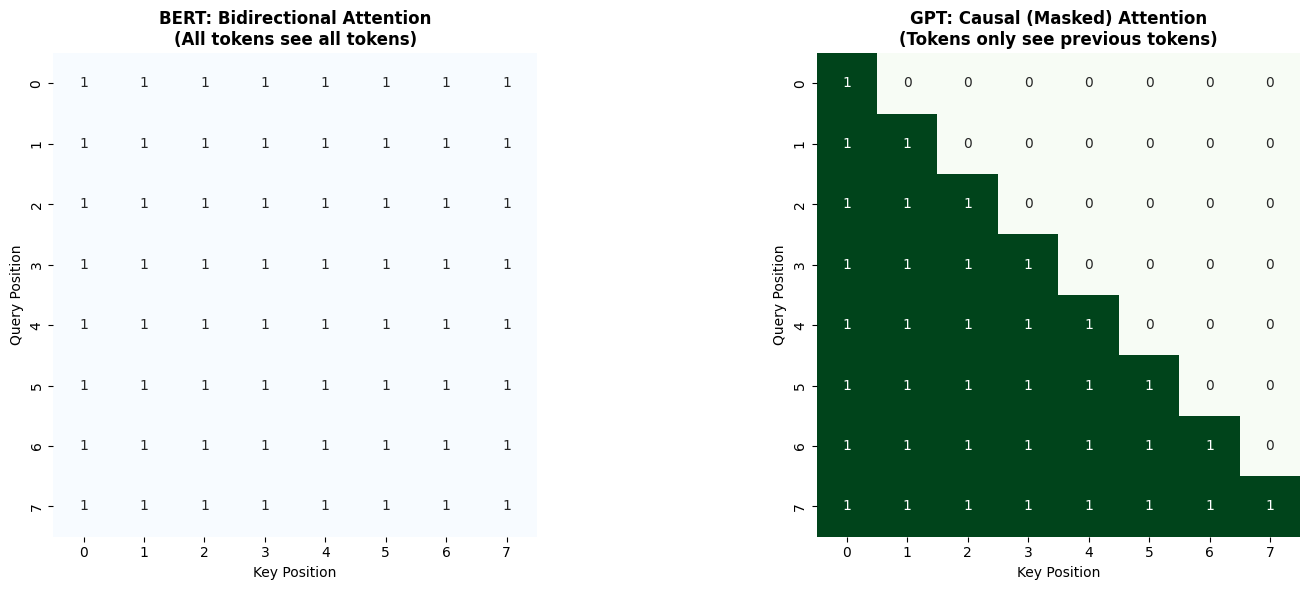


📊 BERT vs GPT Attention:
BERT:  [The] ↔ [cat] ↔ [sat] ↔ [on] ↔ [the] ↔ [mat]
        ↑ All tokens can attend to all positions

GPT:   [The] → [cat] → [sat] → [on] → [the] → [mat]
        ↑ Each token can only attend to previous tokens


In [36]:
# Compare BERT vs GPT attention
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# BERT attention (bidirectional)
ax = axes[0]
bert_mask = np.ones((8, 8))
sns.heatmap(bert_mask, cmap='Blues', annot=True, fmt='.0f', ax=ax, cbar=False, square=True)
ax.set_title('BERT: Bidirectional Attention\n(All tokens see all tokens)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Key Position')
ax.set_ylabel('Query Position')

# GPT attention (causal)
ax = axes[1]
gpt_mask = np.tril(np.ones((8, 8)))
sns.heatmap(gpt_mask, cmap='Greens', annot=True, fmt='.0f', ax=ax, cbar=False, square=True)
ax.set_title('GPT: Causal (Masked) Attention\n(Tokens only see previous tokens)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Key Position')
ax.set_ylabel('Query Position')

plt.tight_layout()
plt.show()

print("\n📊 BERT vs GPT Attention:")
print("=" * 50)
print("BERT:  [The] ↔ [cat] ↔ [sat] ↔ [on] ↔ [the] ↔ [mat]")
print("        ↑ All tokens can attend to all positions")
print("\nGPT:   [The] → [cat] → [sat] → [on] → [the] → [mat]")
print("        ↑ Each token can only attend to previous tokens")

### 2.3 GPT Model Variants

In [37]:
# Compare GPT variants
gpt_variants = {
    'GPT': {
        'gpt2': {'layers': 12, 'params': '117M', 'context': 1024},
        'gpt2-medium': {'layers': 24, 'params': '345M', 'context': 1024},
        'gpt2-large': {'layers': 36, 'params': '774M', 'context': 1024},
        'gpt2-xl': {'layers': 48, 'params': '1.5B', 'context': 1024},
    },
    'GPT-Neo/NeoX (Open Source)': {
        'gpt-neo-125M': {'layers': 12, 'params': '125M', 'context': 2048},
        'gpt-neo-1.3B': {'layers': 24, 'params': '1.3B', 'context': 2048},
        'gpt-neo-2.7B': {'layers': 32, 'params': '2.7B', 'context': 2048},
        'gpt-neox-20b': {'layers': 44, 'params': '20B', 'context': 2048},
    },
    'Llama (Meta)': {
        'llama-7b': {'layers': 32, 'params': '7B', 'context': 4096},
        'llama-13b': {'layers': 40, 'params': '13B', 'context': 4096},
        'llama-70b': {'layers': 80, 'params': '70B', 'context': 4096},
    },
    'Llama 3 (Meta)': {
        'llama-3-8b': {'layers': 32, 'params': '8B', 'context': 8192},
        'llama-3-70b': {'layers': 80, 'params': '70B', 'context': 8192},
    }
}

for family, models in gpt_variants.items():
    print(f"\n📦 {family}")
    print("=" * 60)
    print(f"{'Model':<20} {'Layers':<10} {'Parameters':<15} {'Context':<10}")
    print("-" * 60)
    for model_name, specs in models.items():
        print(f"{model_name:<20} {specs['layers']:<10} {specs['params']:<15} {specs['context']:<10}")


📦 GPT
Model                Layers     Parameters      Context   
------------------------------------------------------------
gpt2                 12         117M            1024      
gpt2-medium          24         345M            1024      
gpt2-large           36         774M            1024      
gpt2-xl              48         1.5B            1024      

📦 GPT-Neo/NeoX (Open Source)
Model                Layers     Parameters      Context   
------------------------------------------------------------
gpt-neo-125M         12         125M            2048      
gpt-neo-1.3B         24         1.3B            2048      
gpt-neo-2.7B         32         2.7B            2048      
gpt-neox-20b         44         20B             2048      

📦 Llama (Meta)
Model                Layers     Parameters      Context   
------------------------------------------------------------
llama-7b             32         7B              4096      
llama-13b            40         13B             4096    

<a name="generation"></a>
## 3. Autoregressive Generation

GPT generates text one token at a time, using its own output as the next input.

In [38]:
# Demonstrate autoregressive generation step by step
def generate_step_by_step(prompt, max_new_tokens=5):
    """Show how GPT generates text token by token."""
    print(f"📝 Prompt: '{prompt}'\n")

    generated_text = prompt

    for step in range(max_new_tokens):
        # Tokenize current text
        inputs = tokenizer(generated_text, return_tensors='pt').to(device)

        # Get model predictions
        with torch.no_grad():
            outputs = model(**inputs)
            logits = outputs.logits

        # Get next token (greedy - highest probability)
        next_token_logits = logits[0, -1, :]
        next_token_id = torch.argmax(next_token_logits).item()
        next_token = tokenizer.decode([next_token_id])

        # Show top 3 predictions
        top_k = torch.topk(next_token_logits, 3)
        print(f"Step {step + 1}:")
        print(f"  Current: '{generated_text}'")
        print(f"  Top 3 predictions:")
        for i, (score, token_id) in enumerate(zip(top_k.values, top_k.indices)):
            token = tokenizer.decode([token_id])
            prob = torch.softmax(next_token_logits, dim=0)[token_id].item()
            marker = " ← SELECTED" if i == 0 else ""
            print(f"    {i+1}. '{token}' (prob: {prob:.4f}){marker}")

        # Append selected token
        generated_text += next_token
        print(f"  Result: '{generated_text}'\n")

    print(f"✅ Final: '{generated_text}'")
    return generated_text

# Run step-by-step generation
generate_step_by_step("The future of AI is", max_new_tokens=5)

📝 Prompt: 'The future of AI is'

Step 1:
  Current: 'The future of AI is'
  Top 3 predictions:
    1. ' uncertain' (prob: 0.0613) ← SELECTED
    2. ' in' (prob: 0.0586)
    3. ' not' (prob: 0.0451)
  Result: 'The future of AI is uncertain'

Step 2:
  Current: 'The future of AI is uncertain'
  Top 3 predictions:
    1. '.' (prob: 0.3467) ← SELECTED
    2. ',' (prob: 0.3224)
    3. ',"' (prob: 0.0403)
  Result: 'The future of AI is uncertain.'

Step 3:
  Current: 'The future of AI is uncertain.'
  Top 3 predictions:
    1. ' The' (prob: 0.0711) ← SELECTED
    2. '
' (prob: 0.0659)
    3. ' But' (prob: 0.0648)
  Result: 'The future of AI is uncertain. The'

Step 4:
  Current: 'The future of AI is uncertain. The'
  Top 3 predictions:
    1. ' future' (prob: 0.0369) ← SELECTED
    2. ' question' (prob: 0.0211)
    3. ' most' (prob: 0.0189)
  Result: 'The future of AI is uncertain. The future'

Step 5:
  Current: 'The future of AI is uncertain. The future'
  Top 3 predictions:
    1. ' of' (

'The future of AI is uncertain. The future of'

<a name="strategies"></a>
## 4. Text Generation Strategies

Different strategies produce different types of output.

In [39]:
# Compare different generation strategies
prompt = "Once upon a time in a distant galaxy,"

strategies = {
    'Greedy': {
        'do_sample': False,
        'num_beams': 1,
    },
    'Beam Search (5 beams)': {
        'do_sample': False,
        'num_beams': 5,
        'early_stopping': True,
    },
    'Sampling (T=1.0)': {
        'do_sample': True,
        'temperature': 1.0,
        'top_k': 50,
    },
    'Nucleus Sampling (top_p=0.9)': {
        'do_sample': True,
        'top_p': 0.9,
        'top_k': 0,
    },
}

print(f"📝 Prompt: '{prompt}'\n")
print("=" * 70)

for strategy_name, params in strategies.items():
    print(f"\n🔹 {strategy_name}")
    print("-" * 50)

    inputs = tokenizer(prompt, return_tensors='pt').to(device)

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=30,
            pad_token_id=tokenizer.eos_token_id,
            **params
        )

    generated = tokenizer.decode(outputs[0], skip_special_tokens=True)
    print(f"  {generated}")

📝 Prompt: 'Once upon a time in a distant galaxy,'


🔹 Greedy
--------------------------------------------------
  Once upon a time in a distant galaxy, the galaxy was a vast, vast, vast, vast, vast, vast, vast, vast, vast, vast, vast, vast, vast,

🔹 Beam Search (5 beams)
--------------------------------------------------
  Once upon a time in a distant galaxy, a group of intelligent beings, known as the Guardians of the Galaxy, came to Earth. The Guardians of the Galaxy, or G.I. Joe

🔹 Sampling (T=1.0)
--------------------------------------------------
  Once upon a time in a distant galaxy, he had seen other stars and he knew they were strange, but he had no idea what they were. For many years, he had lived here in

🔹 Nucleus Sampling (top_p=0.9)
--------------------------------------------------
  Once upon a time in a distant galaxy, the majority of life is thought of as eternally alive, and in some cases even beyond that. Since there is an opportunity to provide Earth with an


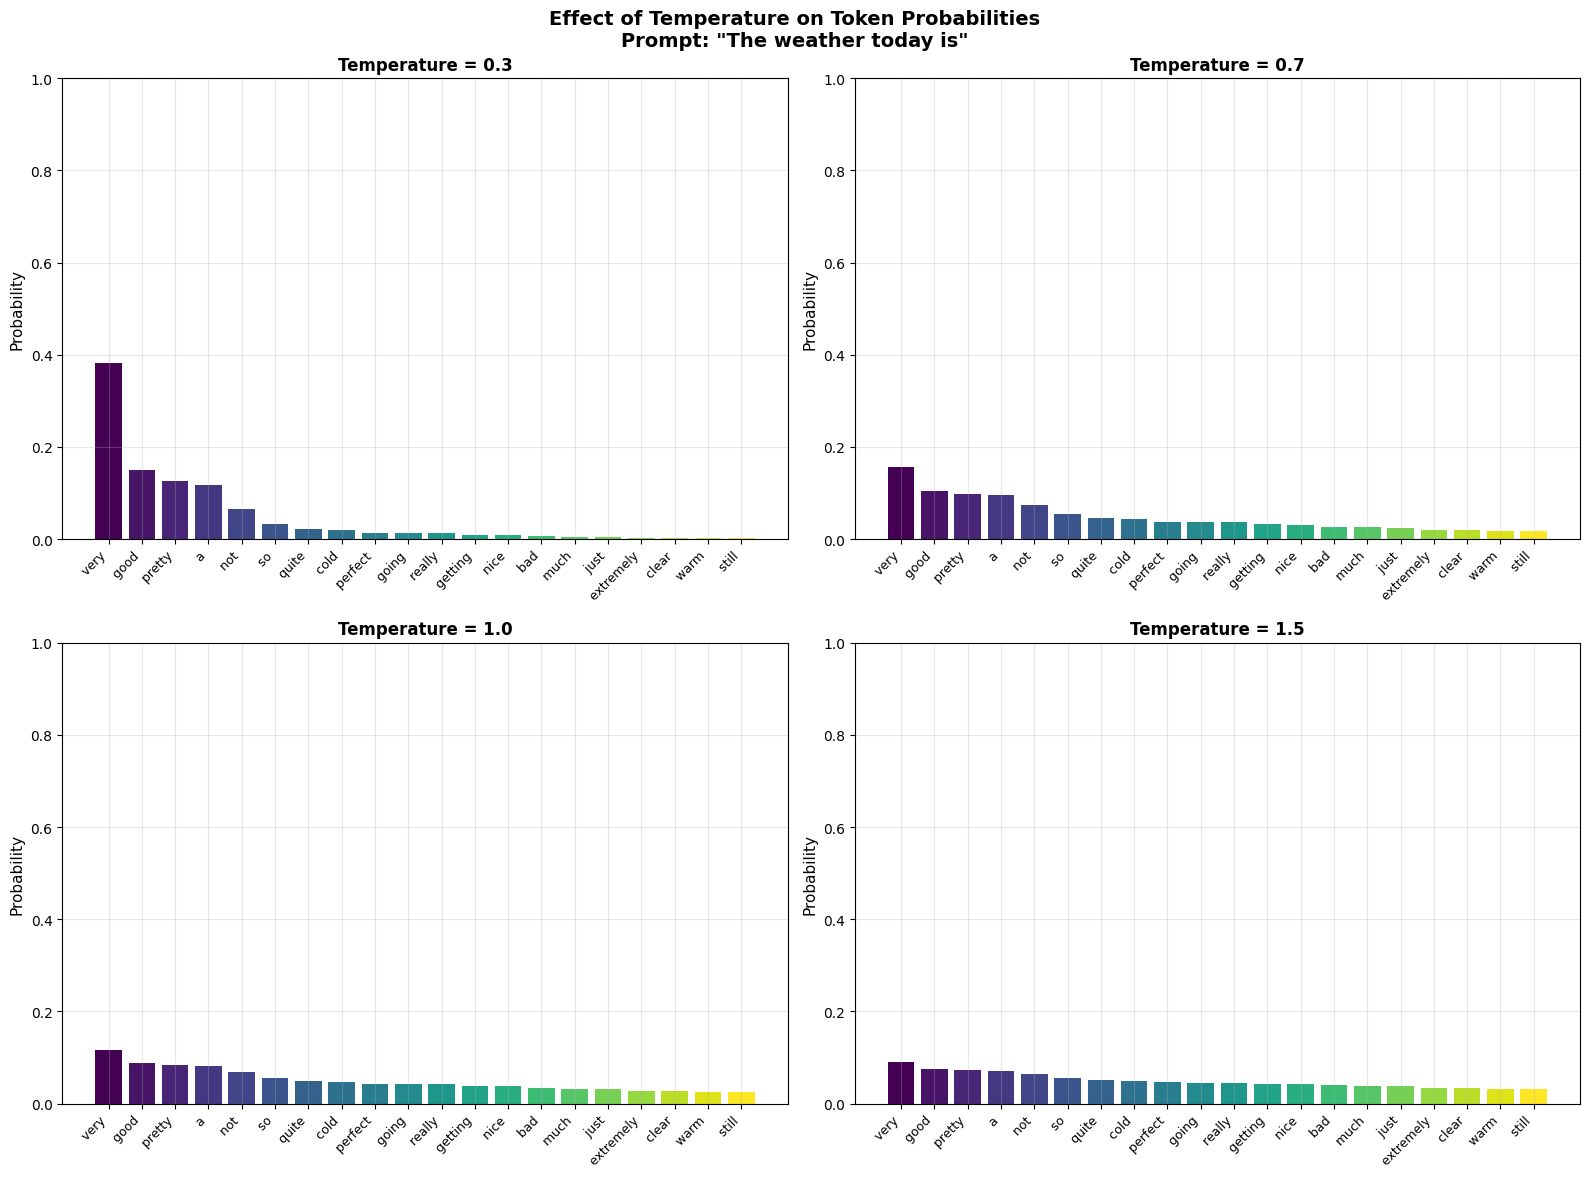


💡 Temperature Effects:
  Low (0.3):  Focused, deterministic, repetitive
  Med (0.7):  Balanced creativity and coherence
  High (1.0): More random, diverse, can be incoherent
  Very High (1.5): Very random, often nonsensical


In [40]:
# Visualize temperature effect on probability distribution
def visualize_temperature(prompt, temperatures=[0.3, 0.7, 1.0, 1.5]):
    """Show how temperature affects token probability distribution."""
    inputs = tokenizer(prompt, return_tensors='pt').to(device)

    with torch.no_grad():
        outputs = model(**inputs)
        logits = outputs.logits[0, -1, :]

    # Get top 20 tokens
    top_k = 20
    top_logits, top_indices = torch.topk(logits, top_k)
    tokens = [tokenizer.decode([idx]) for idx in top_indices]

    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    axes = axes.flatten()

    for idx, temp in enumerate(temperatures):
        # Apply temperature
        probs = torch.softmax(top_logits / temp, dim=0).numpy()

        ax = axes[idx]
        bars = ax.bar(range(top_k), probs, color=plt.cm.viridis(np.linspace(0, 1, top_k)))
        ax.set_xticks(range(top_k))
        ax.set_xticklabels(tokens, rotation=45, ha='right', fontsize=9)
        ax.set_ylabel('Probability', fontsize=11)
        ax.set_title(f'Temperature = {temp}', fontsize=12, fontweight='bold')
        ax.set_ylim(0, 1)
        ax.grid(True, alpha=0.3)

    plt.suptitle(f'Effect of Temperature on Token Probabilities\nPrompt: "{prompt}"',
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

    print("\n💡 Temperature Effects:")
    print("  Low (0.3):  Focused, deterministic, repetitive")
    print("  Med (0.7):  Balanced creativity and coherence")
    print("  High (1.0): More random, diverse, can be incoherent")
    print("  Very High (1.5): Very random, often nonsensical")

visualize_temperature("The weather today is")

<a name="control"></a>
## 5. Controlling Generation

Learn to control output quality and diversity.

In [41]:
def generate_text(
    prompt,
    max_new_tokens=50,
    temperature=0.7,
    top_k=50,
    top_p=0.9,
    repetition_penalty=1.0,
    num_return_sequences=1
):
    """
    Generate text with full control over parameters.
    """
    inputs = tokenizer(prompt, return_tensors='pt').to(device)

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            temperature=temperature,
            top_k=top_k if top_k > 0 else None,
            top_p=top_p if top_p < 1.0 else None,
            repetition_penalty=repetition_penalty,
            num_return_sequences=num_return_sequences,
            do_sample=True,
            pad_token_id=tokenizer.eos_token_id
        )

    results = []
    for output in outputs:
        text = tokenizer.decode(output, skip_special_tokens=True)
        results.append(text)

    return results

<a name="prompting"></a>
## 6. Prompt Engineering for GPT

The way you prompt GPT significantly affects output quality.

In [42]:
# Compare different prompting techniques
prompting_examples = {
    'Basic': "Write a poem about the ocean.",
    'With Context': "You are a romantic poet from the 19th century. Write a poem about the ocean.",
    'With Structure': "Write a 4-line poem about the ocean. Each line should rhyme with 'sea'.",
    'Few-Shot': """Here are examples of ocean poems:

Example 1:
The waves crash upon the sandy shore,
A rhythm that I can't ignore.

Example 2:
Blue and deep, the ocean lies,
Beneath the vast and endless skies.

Now write your own ocean poem:""",
}

print("☑ Prompt Engineering Comparison\n")
print("=" * 70)

for technique, prompt in prompting_examples.items():
    print(f"\n┓ {technique} Prompting")
    print("-" * 50)
    print(f"Prompt: {prompt[:80]}...")
    print("\nOutput:")

    # Fixed: Changed max_length to max_new_tokens
    results = generate_text(prompt, max_new_tokens=100, temperature=0.7)
    print(f"  {results[0]}")
    print()

☑ Prompt Engineering Comparison


┓ Basic Prompting
--------------------------------------------------
Prompt: Write a poem about the ocean....

Output:
  Write a poem about the ocean.

If you are interested in learning more about the ocean, here are some resources that you can use to learn more about it.

The National Oceanic and Atmospheric Administration

The National Oceanic and Atmospheric Administration is the federal agency responsible for ocean science. It is the primary federal agency responsible for monitoring, forecasting, and interpreting the ocean.

The N.O.A. has over 500 offices in nearly 40 states. It is responsible for monitoring, forecasting, and interpreting the


┓ With Context Prompting
--------------------------------------------------
Prompt: You are a romantic poet from the 19th century. Write a poem about the ocean....

Output:
  You are a romantic poet from the 19th century. Write a poem about the ocean.

"I'm not sure what I'm doing here, but I don't think I'

In [43]:
# Demonstrate chain-of-thought prompting
math_problems = {
    'Without CoT': "Q: A store has 50 apples. They sell 15 and get 20 more. How many apples?\nA:",
    'With CoT': """Q: A store has 50 apples. They sell 15 and get 20 more. How many apples?
A: Let's think step by step.
   - Start with 50 apples
   - Sell 15: 50 - 15 = 35 apples
   - Get 20 more: 35 + 20 = 55 apples
   - Answer: 55

Q: A farmer has 30 sheep. 5 escape and he buys 12 more. How many sheep?
A: Let's think step by step.""",
}

print("🧮 Chain-of-Thought Prompting\n")
print("=" * 70)

for method, prompt in math_problems.items():
    print(f"\n🔹 {method}")
    print("-" * 50)

    # Fixed: Using max_new_tokens=50 instead of max_length=100
    results = generate_text(prompt, max_new_tokens=50, temperature=0.3)
    print(results[0])

🧮 Chain-of-Thought Prompting


🔹 Without CoT
--------------------------------------------------
Q: A store has 50 apples. They sell 15 and get 20 more. How many apples?
A: They sell about 20 apples.
Q: What are the prices of apples?
A: They sell about 20 apples.
Q: What are the prices of apples?
A: They sell about 20 apples.
Q: What are the

🔹 With CoT
--------------------------------------------------
Q: A store has 50 apples. They sell 15 and get 20 more. How many apples?
A: Let's think step by step.
   - Start with 50 apples
   - Sell 15: 50 - 15 = 35 apples
   - Get 20 more: 35 + 20 = 55 apples
   - Answer: 55

Q: A farmer has 30 sheep. 5 escape and he buys 12 more. How many sheep?
A: Let's think step by step.
   - Start with 30 sheep

Q: A farmer has 30 sheep. 5 escape and he buys 12 more. How many sheep?

A: Let's think step by step.

Q: A farmer has 30 sheep


<a name="chatbot"></a>
## 7. Building a Simple Chatbot

Let's put it all together to create a chatbot!

In [44]:
class SimpleChatbot:
    """A simple chatbot using GPT-2."""

    def __init__(self, model_name='gpt2', temperature=0.7, max_length=150):
        self.tokenizer = GPT2Tokenizer.from_pretrained(model_name)
        self.model = GPT2LMHeadModel.from_pretrained(model_name)
        self.model.to(device)
        self.temperature = temperature
        self.max_length = max_length
        self.conversation_history = []

        # Set pad token
        self.tokenizer.pad_token = self.tokenizer.eos_token

    def format_prompt(self, user_message):
        """Format the conversation history into a prompt."""
        prompt = "The following is a conversation with a helpful AI assistant.\n\n"

        for exchange in self.conversation_history:
            prompt += f"Human: {exchange['human']}\n"
            prompt += f"AI: {exchange['ai']}\n"

        prompt += f"Human: {user_message}\nAI:"
        return prompt

    def chat(self, user_message):
        """Generate a response to the user message."""
        prompt = self.format_prompt(user_message)

        inputs = self.tokenizer(prompt, return_tensors='pt', padding=True).to(device)

        with torch.no_grad():
            outputs = self.model.generate(
                **inputs,
                max_new_tokens=50,
                temperature=self.temperature,
                top_p=0.9,
                do_sample=True,
                pad_token_id=self.tokenizer.eos_token_id,
                eos_token_id=self.tokenizer.encode('\n')[0]
            )

        # Decode only the new tokens
        response = self.tokenizer.decode(
            outputs[0][len(inputs['input_ids'][0]):],
            skip_special_tokens=True
        )

        # Clean up response
        response = response.split('\n')[0].strip()

        # Update history
        self.conversation_history.append({
            'human': user_message,
            'ai': response
        })

        # Keep only last 5 exchanges
        self.conversation_history = self.conversation_history[-5:]

        return response

    def reset(self):
        """Clear conversation history."""
        self.conversation_history = []
        print("ℑ Conversation history cleared.")

# Create chatbot instance
chatbot = SimpleChatbot(temperature=0.7)
print("™ Chatbot initialized!")
print("   Type your message to chat.")
print("   Use chatbot.reset() to clear history.\n")

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


™ Chatbot initialized!
   Type your message to chat.
   Use chatbot.reset() to clear history.



In [45]:
# Test the chatbot
test_messages = [
    "Hello! What's your name?",
    "Can you explain what machine learning is?",
    "What are some applications of it?",
]

print("🗨️ Chatbot Demo\n")
print("=" * 70)

for message in test_messages:
    print(f"\n👤 You: {message}")
    response = chatbot.chat(message)
    print(f"🤖 Bot: {response}")

🗨️ Chatbot Demo


👤 You: Hello! What's your name?
🤖 Bot: "Nathan"

👤 You: Can you explain what machine learning is?
🤖 Bot: "Nathan"

👤 You: What are some applications of it?
🤖 Bot: "Nathan"
